In [58]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/all unlabeled/oral_normal_3080.jpg
/kaggle/input/all unlabeled/oral_normal_3357.jpg
/kaggle/input/all unlabeled/oral_normal_0983.jpg
/kaggle/input/all unlabeled/oral_normal_1124.jpg
/kaggle/input/all unlabeled/oral_normal_3829.jpg
/kaggle/input/all unlabeled/oral_normal_3515.jpg
/kaggle/input/all unlabeled/oral_normal_1324.jpg
/kaggle/input/all unlabeled/oral_normal_4162.jpg
/kaggle/input/all unlabeled/oral_scc_0771.jpg
/kaggle/input/all unlabeled/oral_scc_0707.jpg
/kaggle/input/all unlabeled/oral_scc_3093.jpg
/kaggle/input/all unlabeled/oral_normal_0952.jpg
/kaggle/input/all unlabeled/oral_normal_4147.jpg
/kaggle/input/all unlabeled/oral_scc_0480.jpg
/kaggle/input/all unlabeled/oral_scc_0654.jpg
/kaggle/input/all unlabeled/oral_normal_1627.jpg
/kaggle/input/all unlabeled/oral_scc_0620.jpg
/kaggle/input/all unlabeled/oral_normal_1034.jpg
/kaggle/input/all unlabeled/oral_scc_3567.jpg
/kaggle/input/all unlabeled/oral_scc_1208.jpg
/kaggle/input/all unlabeled/oral_scc_0761.jp

In [59]:
!pip install torch torchvision matplotlib numpy tqdm

In [60]:
! pip install efficientnet_pytorch

In [61]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.manifold import TSNE
from torch.cuda.amp import autocast, GradScaler
import os
import torch.optim as optim
from efficientnet_pytorch import EfficientNet  # pip install efficientnet_pytorch
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier

In [62]:
# Set environment to reduce memory fragmentation
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [63]:
# Set random seed for reproducibility
torch.manual_seed(42)

In [64]:
# Custom Dataset for Unlabeled Images (with two augmentations)
class OralCancerDataset(Dataset):
    def __init__(self, image_paths, transform1, transform2):
        self.image_paths = image_paths
        self.transform1 = transform1
        self.transform2 = transform2

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        view1 = self.transform1(image)
        view2 = self.transform2(image)
        return view1, view2

In [65]:
# Define wrapper for downstream task (single image + label) - Simplified since base uses None transform
class DownstreamWrapper(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        item = self.subset[idx]
        if len(item) == 3:  # From aug dataset, ignore img2
            img, _, label = item
        else:  # From base (PIL, label)
            img, label = item
        if self.transform:
            img = self.transform(img)
        return img, label

In [66]:
# Projector MLP
class Projector(nn.Module):
    def __init__(self, in_dim, hidden_dim=2048, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, x):
        return self.net(x)

In [67]:
# Define SimCLR model
class SimCLR(nn.Module):
    def __init__(self, base_encoder, projection_dim=128):
        super(SimCLR, self).__init__()
        self.encoder = base_encoder
        self.encoder.classifier = nn.Identity()  # Remove the final classifier to get 1280 features
        self.feature_dim = 1280  # EfficientNet-B0 feature dim after avgpool
        self.projection_head = nn.Sequential(
            nn.Linear(self.feature_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, projection_dim)
        )
    
    def forward(self, x):
        h = self.encoder(x)  # (batch, 1280)
        z = self.projection_head(h)
        return F.normalize(z, dim=1)  # L2 normalization

In [68]:
# Define NT-Xent loss
def nt_xent_loss(z1, z2, temperature=0.5):
    batch_size = z1.size(0)
    z = torch.cat([z1, z2], dim=0)  # [2N, projection_dim]
    sim_matrix = F.cosine_similarity(z.unsqueeze(1), z.unsqueeze(0), dim=2) / temperature
    # Correct labels for positive pairs
    labels = torch.cat([torch.arange(batch_size, 2 * batch_size), torch.arange(batch_size)]).to(z1.device)
    # Mask self-similarities (diagonal) to -inf
    mask = torch.eye(2 * batch_size, device=z1.device).bool()
    sim_matrix = sim_matrix.masked_fill(mask, -float('inf'))
    loss = F.cross_entropy(sim_matrix, labels)
    return loss

In [69]:
# Data transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

downstream_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [70]:
# Define OralCancerSimCLRDataset (assumed based on usage)
class OralCancerSimCLRDataset(Dataset):
    def __init__(self, data_path, transform=None):
        self.data_path = data_path
        self.transform = transform
        self.image_paths = [os.path.join(data_path, f) for f in os.listdir(data_path) if f.endswith('.jpg')]
        self.labels = [0 if 'normal' in os.path.basename(p) else 1 for p in self.image_paths]  # 0=Non-Cancer, 1=Cancer

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            img1 = self.transform(image)
            img2 = self.transform(image) if self.transform else image
            return img1, img2, label
        return image, label

aug_dataset = OralCancerSimCLRDataset(data_path=data_path, transform=transform)  # For pre-training
print(f"Found {len(aug_dataset)} images")

Found 10002 images


In [71]:
# Load dataset for pre-training (with aug)
data_path = '/kaggle/input/all unlabeled'
if not os.path.exists(data_path):
    raise ValueError(f"Data path {data_path} does not exist. Run '!ls /kaggle/input/' to check.")
print(f"Loading dataset from {data_path}")

aug_dataset = OralCancerSimCLRDataset(data_path=data_path, transform=transform)  # For pre-training
print(f"Found {len(aug_dataset)} images")

Loading dataset from /kaggle/input/all unlabeled
Found 10002 images


In [72]:
# Split indices
pretrain_size = int(0.5 * len(aug_dataset))  # ~8001
remaining_size = len(aug_dataset) - pretrain_size  # ~2001
pretrain_split, remaining_split = random_split(aug_dataset, [pretrain_size, remaining_size])
pretrain_indices = pretrain_split.indices
remaining_indices = remaining_split.indices
print(f"Pretrain dataset size: {len(pretrain_indices)}")
print(f"Remaining dataset size: {len(remaining_indices)}")

Pretrain dataset size: 5001
Remaining dataset size: 5001


In [73]:
# Pre-training loader (uses aug_dataset subset)
train_loader = DataLoader(pretrain_split, batch_size=32, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)

In [74]:
# Pre-training loader (uses aug_dataset subset)
train_loader = DataLoader(pretrain_split, batch_size=32, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)

In [75]:
# Create base dataset without transform (for downstream, t-SNE, test - PIL images)
base_dataset = OralCancerSimCLRDataset(data_path=data_path, transform=None)

In [76]:
# Downstream dataset (same 80% indices, but from base)
downstream_subset = torch.utils.data.Subset(base_dataset, pretrain_indices)
downstream_dataset = DownstreamWrapper(downstream_subset, downstream_transform)
train_size = int(0.5 * len(downstream_dataset))  # ~5601
val_size = len(downstream_dataset) - train_size  # ~2400
downstream_train_split, downstream_val_split = random_split(downstream_dataset, [train_size, val_size])

In [77]:
# Downstream loaders
train_loader_downstream = DataLoader(downstream_train_split, batch_size=32, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
val_loader_downstream = DataLoader(downstream_val_split, batch_size=32, shuffle=False, num_workers=2, pin_memory=True, drop_last=True)

In [78]:
# Test loader (20% holdout from base)
test_subset = torch.utils.data.Subset(base_dataset, remaining_indices)
test_dataset = DownstreamWrapper(test_subset, downstream_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True, drop_last=True)

In [79]:
# Initialize SimCLR model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
base_encoder = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
model = SimCLR(base_encoder).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scaler = torch.amp.GradScaler(device)

In [80]:
# Clear GPU cache before training (Fix OOM)
torch.cuda.empty_cache()

In [81]:
num_epochs = 100
pretrain_losses = []
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader, desc=f"Pretrain Epoch {epoch+1}/{num_epochs}"):
        img1, img2, _ = batch
        img1, img2 = img1.to(device), img2.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast(device_type='cuda'):  # Fixed for compatibility
            z1 = model(img1)
            z2 = model(img2)
            loss = nt_xent_loss(z1, z2, temperature=0.5)
        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    pretrain_losses.append(avg_loss)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")
    torch.cuda.empty_cache()  # Clear cache after each epoch

Pretrain Epoch 1/100: 100%|██████████| 156/156 [01:09<00:00,  2.26it/s]


Epoch 1, Loss: 3.1196


Pretrain Epoch 2/100: 100%|██████████| 156/156 [01:09<00:00,  2.26it/s]


Epoch 2, Loss: 2.5968


Pretrain Epoch 3/100: 100%|██████████| 156/156 [01:08<00:00,  2.27it/s]


...

Epoch 98, Loss: 2.2288


Pretrain Epoch 99/100: 100%|██████████| 156/156 [01:08<00:00,  2.28it/s]


Epoch 99, Loss: 2.2287


Pretrain Epoch 100/100: 100%|██████████| 156/156 [01:09<00:00,  2.25it/s]

Epoch 100, Loss: 2.2283


In [82]:
# Save pretrained model
torch.save(model.state_dict(), 'simclr_pretask_efficientnetb0.pth')

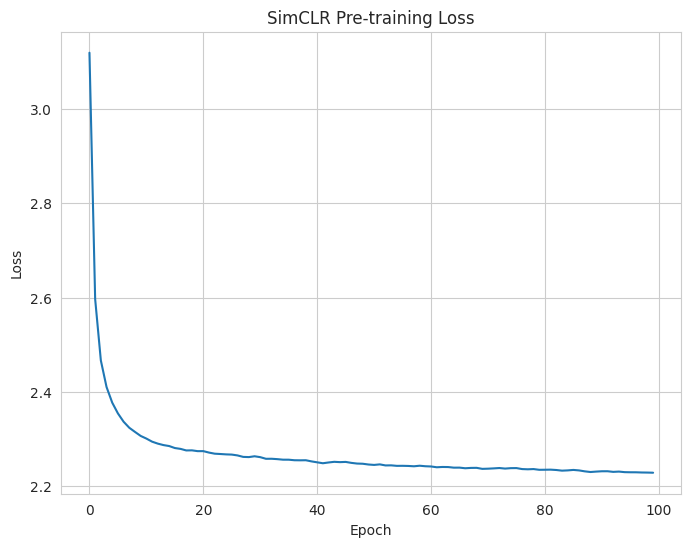

In [83]:
# Plot pre-training loss
plt.figure(figsize=(8, 6))
plt.plot(pretrain_losses)
plt.title('SimCLR Pre-training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.savefig('pretrain_loss.png')
plt.show()

In [84]:
# t-SNE Visualization
model.eval()

SimCLR(
  (encoder): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
              (scale_activa

Extracting features for t-SNE: 100%|██████████| 157/157 [00:17<00:00,  8.85it/s]


Running t-SNE on pretrain dataset features...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 5001 samples in 0.003s...
[t-SNE] Computed neighbors for 5001 samples in 0.900s...
[t-SNE] Computed conditional probabilities for sample 1000 / 5001
[t-SNE] Computed conditional probabilities for sample 2000 / 5001
[t-SNE] Computed conditional probabilities for sample 3000 / 5001
[t-SNE] Computed conditional probabilities for sample 4000 / 5001
[t-SNE] Computed conditional probabilities for sample 5000 / 5001
[t-SNE] Computed conditional probabilities for sample 5001 / 5001
[t-SNE] Mean sigma: 7.371876
[t-SNE] KL divergence after 250 iterations with early exaggeration: 67.245621
[t-SNE] KL divergence after 1000 iterations: 0.594806


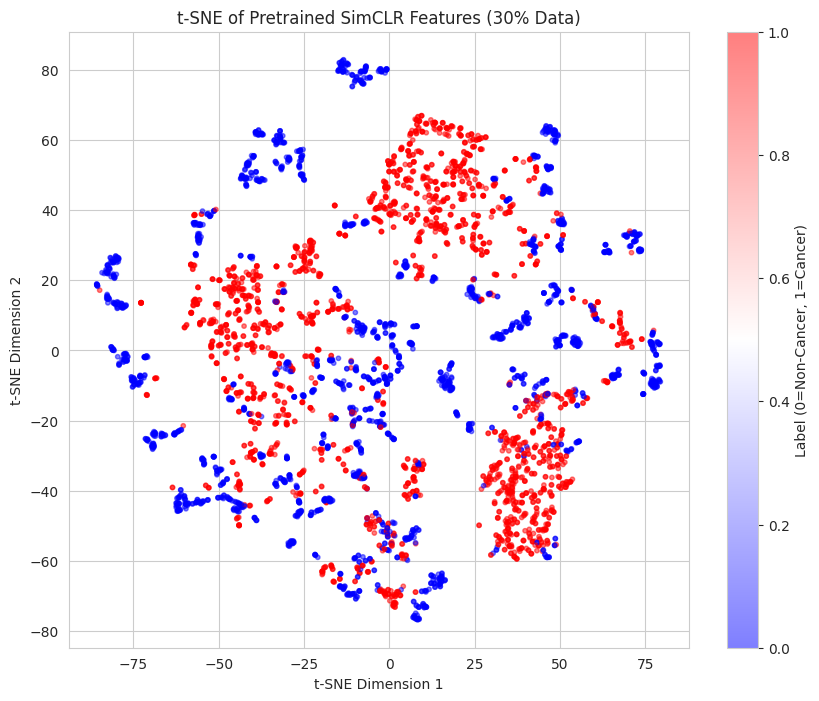

t-SNE plot saved as 'tsne_simclr_pretrain.png'


In [85]:
# Use base_dataset subset for t-SNE (PIL, then transform)
tsne_subset = torch.utils.data.Subset(base_dataset, pretrain_indices)
tsne_wrapper = DownstreamWrapper(tsne_subset, transform=downstream_transform)
tsne_loader = DataLoader(tsne_wrapper, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

features = []
labels = []
with torch.no_grad():
    for batch in tqdm(tsne_loader, desc="Extracting features for t-SNE"):
        img, label = batch  # Single img
        img = img.to(device)
        feature = model.encoder(img)
        feature = feature.view(feature.size(0), -1)
        features.append(feature.cpu().numpy())
        labels.append(label.numpy())
features = np.concatenate(features, axis=0)
labels = np.concatenate(labels, axis=0)

print("Running t-SNE on pretrain dataset features...")
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42, verbose=1)
tsne_features = tsne.fit_transform(features)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(tsne_features[:, 0], tsne_features[:, 1], c=labels, cmap='bwr', alpha=0.5, s=10)
plt.colorbar(scatter, label='Label (0=Non-Cancer, 1=Cancer)')
plt.title('t-SNE of Pretrained SimCLR Features (30% Data)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.savefig('tsne_simclr_pretrain.png')
plt.show()
print("t-SNE plot saved as 'tsne_simclr_pretrain.png'")

In [86]:
# Downstream classification with Random Forest
num_epochs_cls = 100
# Extract features from pre-trained encoder
model.eval()
train_features, train_labels = [], []
with torch.no_grad():
    for img, label in train_loader_downstream:
        img = img.to(device)
        feature = model.encoder(img).view(img.size(0), -1).cpu().numpy()
        train_features.append(feature)
        train_labels.append(label.numpy())
train_features = np.concatenate(train_features, axis=0)
train_labels = np.concatenate(train_labels, axis=0)

val_features, val_labels = [], []
with torch.no_grad():
    for img, label in val_loader_downstream:
        img = img.to(device)
        feature = model.encoder(img).view(img.size(0), -1).cpu().numpy()
        val_features.append(feature)
        val_labels.append(label.numpy())
val_features = np.concatenate(val_features, axis=0)
val_labels = np.concatenate(val_labels, axis=0)

# Train Random Forest
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(train_features, train_labels)

# Validate
val_pred = rf_classifier.predict(val_features)
val_acc = (val_pred == val_labels).mean()
print(f"Validation Accuracy: {val_acc:.4f}")

Validation Accuracy: 0.9435


In [87]:
# Test evaluation
test_features, test_labels = [], []
with torch.no_grad():
    for img, label in test_loader:
        img = img.to(device)
        feature = model.encoder(img).view(img.size(0), -1).cpu().numpy()
        test_features.append(feature)
        test_labels.append(label.numpy())
test_features = np.concatenate(test_features, axis=0)
test_labels = np.concatenate(test_labels, axis=0)

test_pred = rf_classifier.predict(test_features)
test_acc = (test_pred == test_labels).mean()
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.9393


In [88]:
# Import necessary libraries for visualizations
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

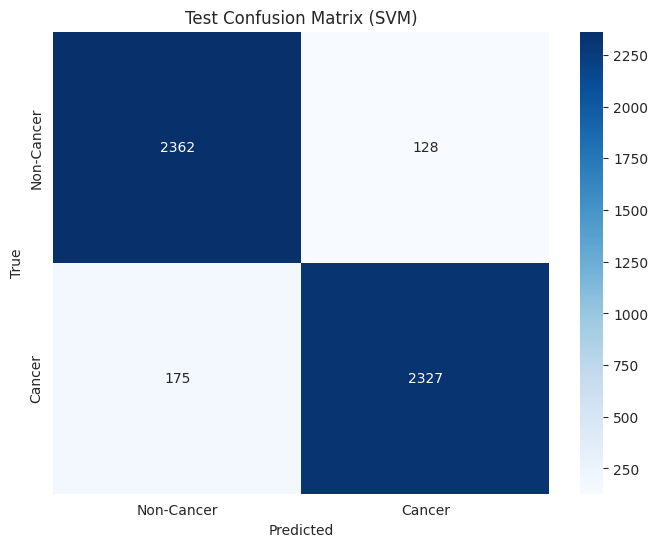

In [89]:
# Confusion matrix
cm = confusion_matrix(test_labels, test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Cancer', 'Cancer'], yticklabels=['Non-Cancer', 'Cancer'])
plt.title('Test Confusion Matrix (SVM)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.savefig('test_cm_svm.png')
plt.show()

In [90]:
# Classification report
print(classification_report(test_labels, test_pred, target_names=['Non-Cancer', 'Cancer']))

              precision    recall  f1-score   support

  Non-Cancer       0.93      0.95      0.94      2490
      Cancer       0.95      0.93      0.94      2502

    accuracy                           0.94      4992
   macro avg       0.94      0.94      0.94      4992
weighted avg       0.94      0.94      0.94      4992



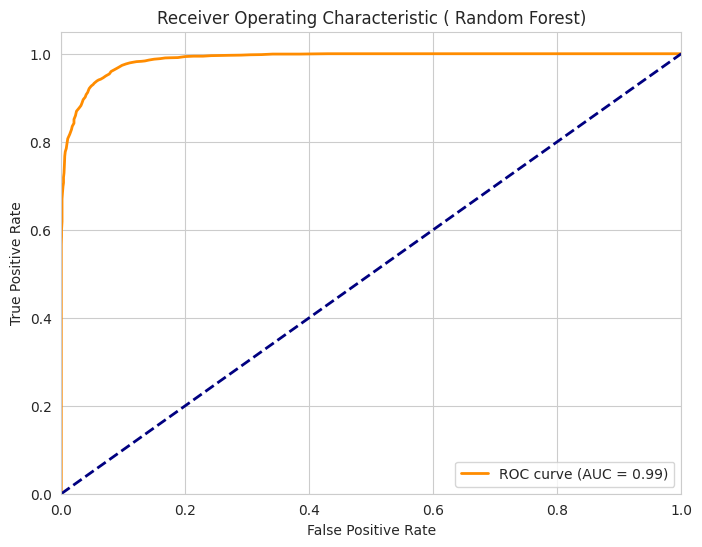

In [91]:
# ROC Curve
test_prob = rf_classifier.predict_proba(test_features)[:, 1]  # Probability for the positive class (Cancer)
fpr, tpr, _ = roc_curve(test_labels, test_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic ( Random Forest)')
plt.legend(loc='lower right')
plt.savefig('roc_curve_svm.png')
plt.show()

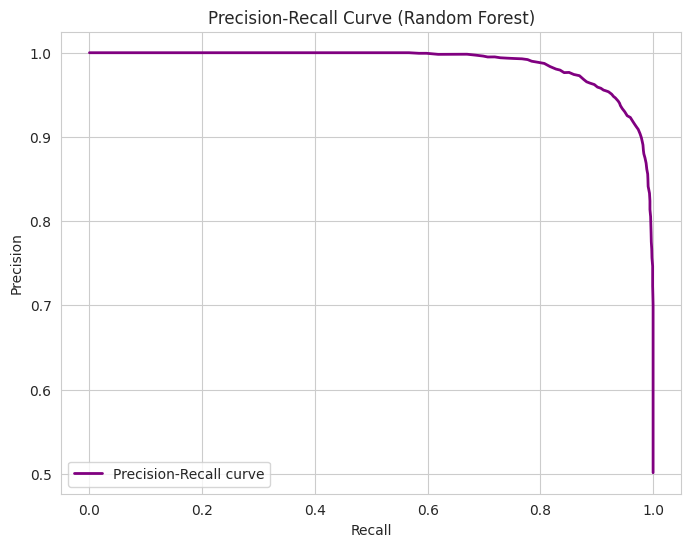

In [92]:
# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(test_labels, test_prob)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='purple', lw=2, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Random Forest)')
plt.legend(loc='lower left')
plt.savefig('pr_curve_svm.png')
plt.show()

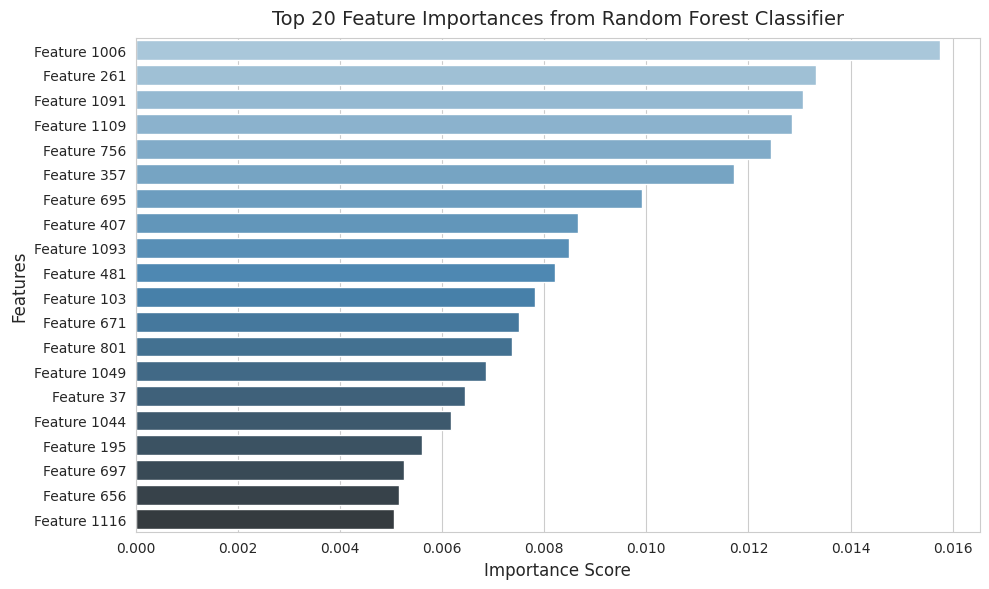

In [93]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Number of top features to display
top_n = 20

# Get feature importances from the Random Forest classifier
importances = rf_classifier.feature_importances_
indices = np.argsort(importances)[::-1][:top_n]  # Indices of top N features
feature_names = [f"Feature {i}" for i in indices]  # Label features (e.g., Feature 0, Feature 1, ...)
importances_top = importances[indices]

# Create a DataFrame for plotting
df_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances_top
})

# Set Seaborn style for better aesthetics
sns.set_style("whitegrid")

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_importances, palette='Blues_d')
plt.title('Top {} Feature Importances from Random Forest Classifier'.format(top_n), fontsize=14, pad=10)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()

# Save the plot
plt.savefig('feature_importance_rf.png', dpi=300, bbox_inches='tight')
plt.show()

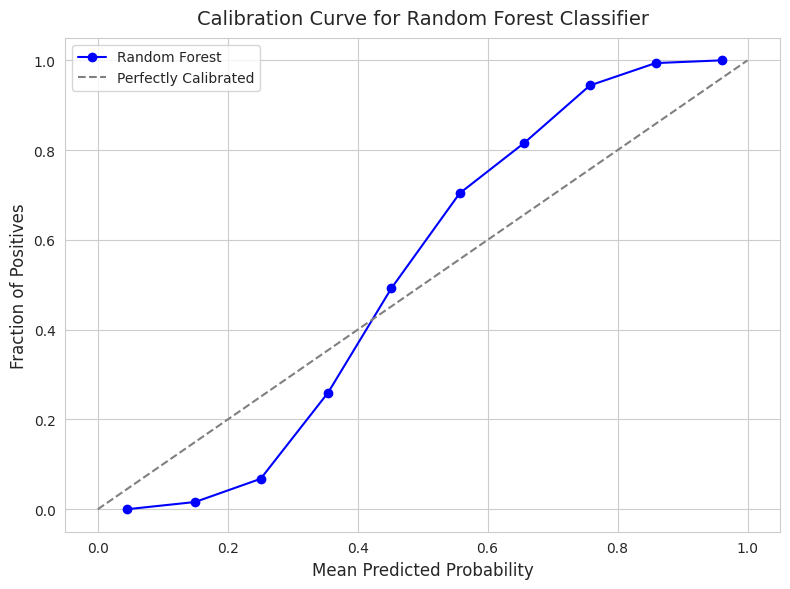

In [94]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.calibration import calibration_curve

# Get predicted probabilities for the positive class (Cancer, assuming label 1)
test_prob = rf_classifier.predict_proba(test_features)[:, 1]

# Compute calibration curve
prob_true, prob_pred = calibration_curve(test_labels, test_prob, n_bins=10, strategy='uniform')

# Set Seaborn style for better aesthetics
sns.set_style("whitegrid")

# Create the calibration plot
plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', linestyle='-', color='blue', label='Random Forest')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability', fontsize=12)
plt.ylabel('Fraction of Positives', fontsize=12)
plt.title('Calibration Curve for Random Forest Classifier', fontsize=14, pad=10)
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()

# Save the plot
plt.savefig('calibration_curve_rf.png', dpi=300, bbox_inches='tight')
plt.show()

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


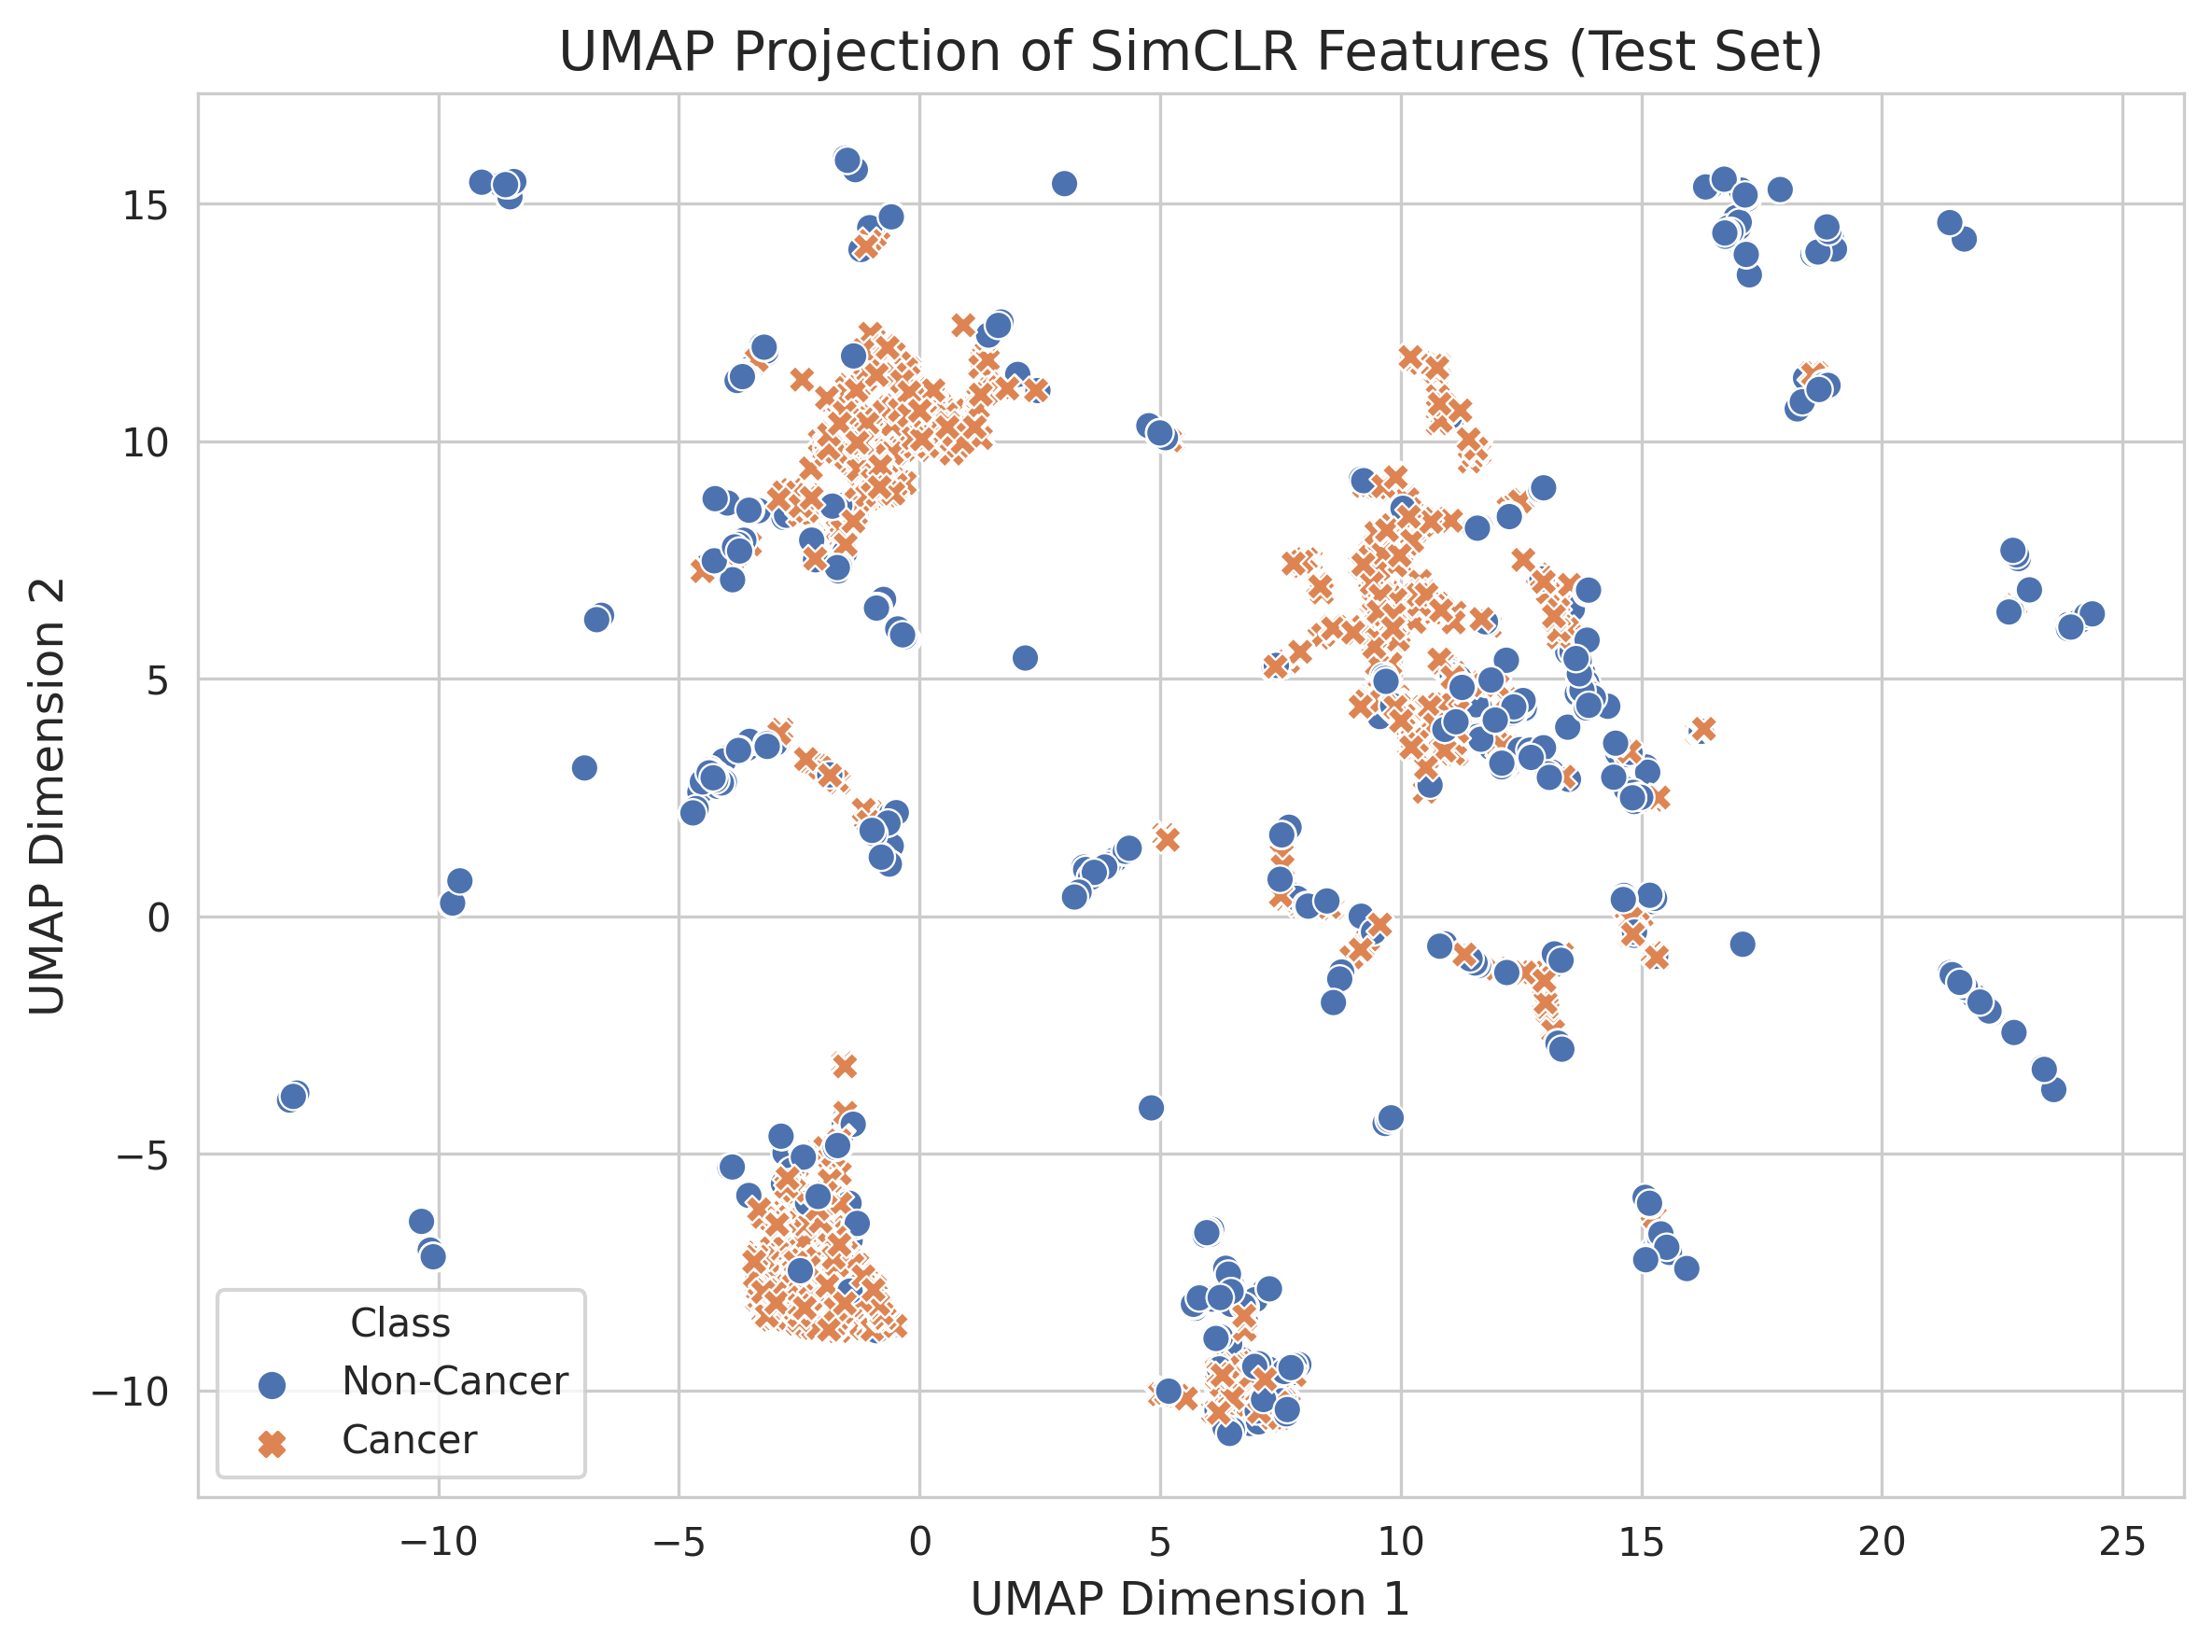

In [95]:
import umap
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Perform UMAP reduction
reducer = umap.UMAP(n_components=2, random_state=42)
umap_embeddings = reducer.fit_transform(test_features)

# Create DataFrame for plotting
df_umap = pd.DataFrame({
    'UMAP1': umap_embeddings[:, 0],
    'UMAP2': umap_embeddings[:, 1],
    'Label': ['Non-Cancer' if label == 0 else 'Cancer' for label in test_labels]
})

# Plot UMAP
plt.figure(figsize=(8, 6), dpi=300)
sns.scatterplot(x='UMAP1', y='UMAP2', hue='Label', style='Label', palette='deep', data=df_umap, s=50)
plt.title('UMAP Projection of SimCLR Features (Test Set)', fontsize=14)
plt.xlabel('UMAP Dimension 1', fontsize=12)
plt.ylabel('UMAP Dimension 2', fontsize=12)
plt.legend(title='Class', loc='best')
plt.tight_layout()
plt.savefig('umap_simclr_features.png', dpi=300, bbox_inches='tight')
plt.show()